In [1]:
from platosim.simfile import SimFile
from platosim.simulation import Simulation
from platosim.validation import switchOffAllEffects
import os
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import math

In [12]:
sim = Simulation("Gain")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# Single-pixel exposures

numExposures = 1
sim["ObservingParameters/NumExposures"] = numExposures
sim["SubField/NumRows"] = 4510
sim["SubField/NumColumns"] = 4510

sim["CCD/IncludeDigitalSaturation"] = "yes"
sim["FEE/ElectronicOffset/RefValue"] = 0
sim["FEE/ElectronicOffset/Stability"] = 0

sim["ObservingParameters/DecPointing"] = -sim["ObservingParameters/DecPointing"]

# Nominal operating temperature

In [13]:
outputWithoutGain = np.ravel(sim.run(removeOutputFile = True).getImage(0))

sim["CCD/IncludeQuantisation"] = "yes"

outputWithGain = np.ravel(sim.run(removeOutputFile = True).getImage(0))


2020-05-20 16:07:51 WARNING Simulation: no information about detected stars to write to HDF5
2020-05-20 16:07:51 WARNING Camera: No star positions to write to HDF5 file.


2020-05-20 16:07:52 WARNING Simulation: no information about detected stars to write to HDF5
2020-05-20 16:07:52 WARNING Camera: No star positions to write to HDF5 file.



In [14]:
flux = np.unique(outputWithoutGain)[0]

In [15]:
saturationLimit = sim["CCD/DigitalSaturation"]
print(saturationLimit)

65535


In [16]:
gain = sim["FEE/Gain/RefValueLeft"] * sim["CCD/Gain/RefValueLeft"]
print(1 / gain)

quotient = np.floor((outputWithoutGain * gain)) / outputWithGain
quotient = quotient[outputWithoutGain < saturationLimit]
print(np.min(quotient), np.max(quotient))

25.025025025025023
1.0 1.0


# Temperature dependency

In [17]:
numExposures = 100
sim["ObservingParameters/NumExposures"] = numExposures

sim["SubField/NumRows"] = 1
sim["SubField/NumColumns"] = 1

deltaTemperature = 10
time = np.array([0, (numExposures - 1) * 25])

In [18]:
print([0, numExposures - 1])
temperature = np.array([sim["FEE/NominalOperatingTemperature"], sim["FEE/NominalOperatingTemperature"] + deltaTemperature])
print(temperature)

[0, 99]
[210.15 220.15]


## Left half

### Temperature dependency of the FEE

In [19]:
temperature = np.array([sim["FEE/NominalOperatingTemperature"], sim["FEE/NominalOperatingTemperature"] + deltaTemperature])

sim["FEE/Temperature"] = "FromFile"
temperatureFilename = os.environ["PLATO_WORKDIR"] + "temperature.txt"
sim["FEE/TemperatureFileName"] = temperatureFilename

np.savetxt(temperatureFilename, np.c_[time, temperature])

sim["CCD/IncludeQuantisation"] = "yes"

output = sim.run(removeOutputFile = True)
print(temperature)


2020-05-20 16:07:56 WARNING Simulation: no information about detected stars to write to HDF5
2020-05-20 16:07:56 WARNING Camera: No star positions to write to HDF5 file.

[210.15 220.15]


In [26]:
feeGain = np.array([])

for exposure in range(numExposures):
    
    output.getImage(exposure)
    feeGain = np.append(feeGain, output.getImage(exposure)[0][0])

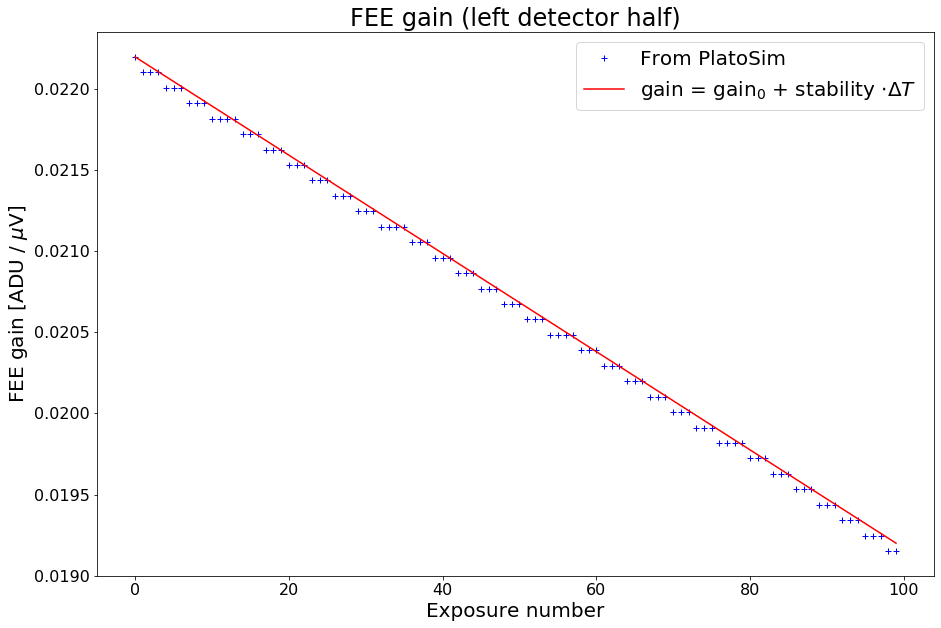

In [28]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

feeGain /= feeGain[0]
feeGain *= sim["FEE/Gain/RefValueLeft"]
plt.plot(feeGain, "b+", label="From PlatoSim")



##########################################################
# Linear decrease in FEE gain with increase in temperature
##########################################################

feeSlope = (temperature[-1] - temperature[0]) / (numExposures - 1) * sim["FEE/Gain/Stability"]
exposures = np.arange(0, numExposures)

plt.plot(sim["FEE/Gain/RefValueLeft"] + feeSlope * exposures, "r", label = "gain = gain$_0$ + stability $\\cdot \\Delta T$")



########
# Layout
########

plt.title("FEE gain (left detector half)", fontsize = 24)
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("FEE gain [ADU / $\mu$V]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

### Temperature dependency of the CCD

In [30]:
numExposures = 100
sim["ObservingParameters/NumExposures"] = numExposures
cycleTime = sim["ObservingParameters/CycleTime"]
time = np.array([0, numExposures * cycleTime])

temperature = np.array([sim["CCD/NominalOperatingTemperature"], sim["CCD/NominalOperatingTemperature"] + 5 * deltaTemperature])

sim["FEE/Temperature"] = "Nominal"
sim["CCD/Temperature"] = "FromFile"
temperatureFilename = os.environ["PLATO_WORKDIR"] + "temperature.txt"
sim["CCD/TemperatureFileName"] = temperatureFilename

np.savetxt(temperatureFilename, np.c_[time, temperature])

output = sim.run(removeOutputFile = True)
print(temperature)


2020-05-20 16:09:27 WARNING Simulation: no information about detected stars to write to HDF5
2020-05-20 16:09:27 WARNING Camera: No star positions to write to HDF5 file.

[203.15 253.15]


In [31]:
ccdGain = np.array([])

for exposure in range(numExposures):
    
    output.getImage(exposure)
    ccdGain = np.append(ccdGain, output.getImage(exposure)[0][0])

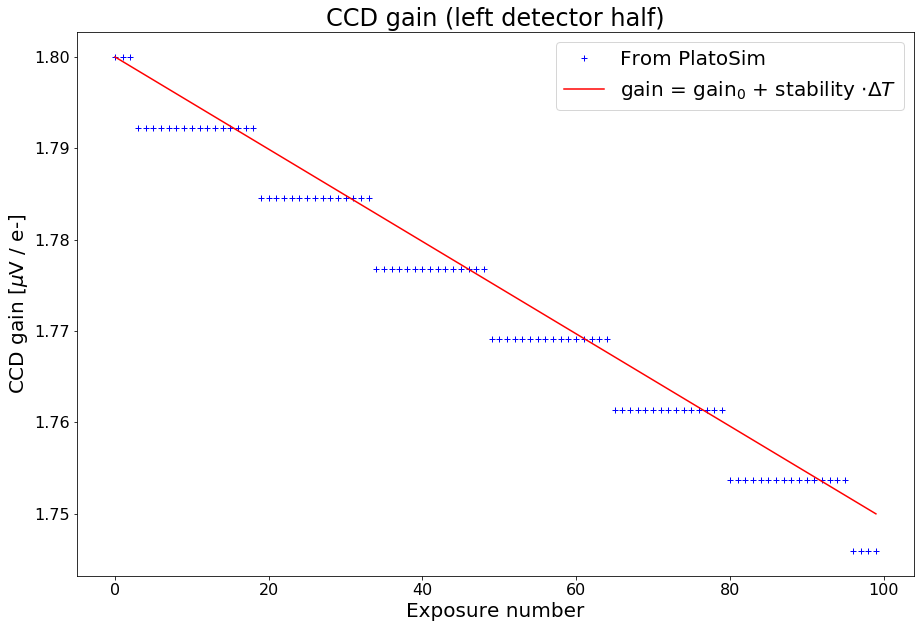

In [32]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############


ccdGain /= ccdGain[0]
ccdGain *= sim["CCD/Gain/RefValueLeft"]
plt.plot(ccdGain, "b+", label="From PlatoSim")



##########################################################
# Linear decrease in FEE gain with increase in temperature
##########################################################

ccdSlope = (temperature[-1] - temperature[0]) / (numExposures - 1) * sim["CCD/Gain/Stability"]
exposures = np.arange(0, numExposures)
plt.plot(sim["CCD/Gain/RefValueLeft"] + ccdSlope * exposures, "r", label = "gain = gain$_0$ + stability $\\cdot \\Delta T$")



########
# Layout
########

plt.title("CCD gain (left detector half)", fontsize = 24)
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("CCD gain [$\mu$V / e-]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

## Right half

In [33]:
sim["SubField/ZeroPointColumn"] = 3000

### Temperature dependency of the FEE

In [34]:
temperature = np.array([sim["FEE/NominalOperatingTemperature"], sim["FEE/NominalOperatingTemperature"] + deltaTemperature])

sim["FEE/Temperature"] = "FromFile"
temperatureFilename = os.environ["PLATO_WORKDIR"] + "temperature.txt"
sim["FEE/TemperatureFileName"] = temperatureFilename

np.savetxt(temperatureFilename, np.c_[time, temperature])

In [35]:
output = sim.run(removeOutputFile = True)


2020-05-20 16:09:29 WARNING Simulation: no information about detected stars to write to HDF5
2020-05-20 16:09:30 WARNING Camera: No star positions to write to HDF5 file.



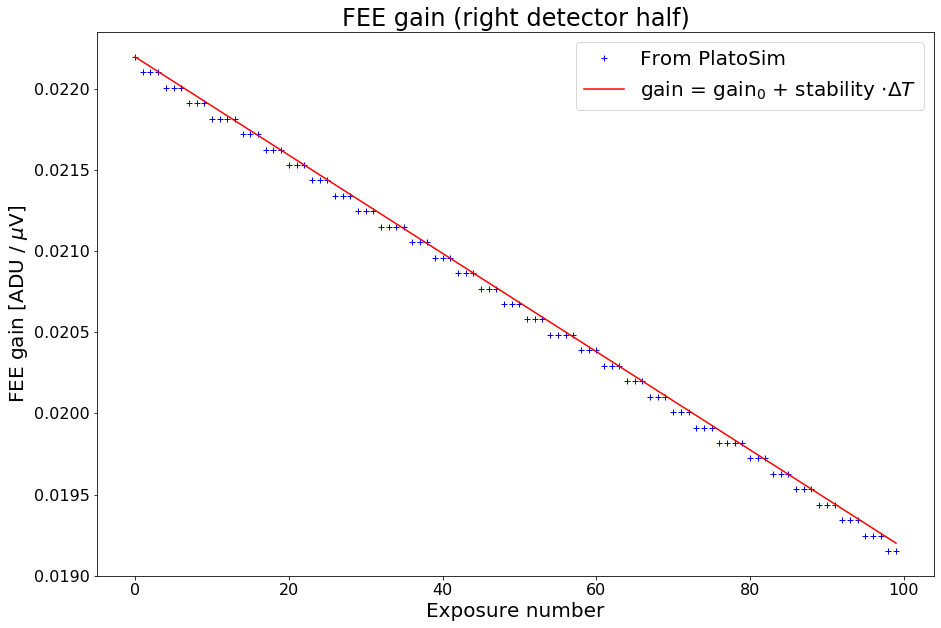

In [36]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############


feeGain /= feeGain[0]
feeGain *= sim["FEE/Gain/RefValueRight"]
plt.plot(feeGain, "b+", label="From PlatoSim")



##########################################################
# Linear decrease in FEE gain with increase in temperature
##########################################################

feeSlope = (temperature[-1] - temperature[0]) / (numExposures - 1) * sim["FEE/Gain/Stability"]
exposures = np.arange(0, numExposures)
plt.plot(sim["FEE/Gain/RefValueRight"] + feeSlope * exposures, "r", label = "gain = gain$_0$ + stability $\\cdot \\Delta T$")

########
# Layout
########

plt.title("FEE gain (right detector half)", fontsize = 24)
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("FEE gain [ADU / $\mu$V]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

### Temperature dependency of the CCD

In [37]:
temperature = np.array([sim["CCD/NominalOperatingTemperature"], sim["CCD/NominalOperatingTemperature"] + 5 * deltaTemperature])

sim["FEE/Temperature"] = "Nominal"
sim["CCD/Temperature"] = "FromFile"
temperatureFilename = os.environ["PLATO_WORKDIR"] + "temperature.txt"
sim["CCD/TemperatureFileName"] = temperatureFilename

np.savetxt(temperatureFilename, np.c_[time, temperature])

In [38]:
output = sim.run(removeOutputFile = True)


2020-05-20 16:09:31 WARNING Simulation: no information about detected stars to write to HDF5
2020-05-20 16:09:31 WARNING Camera: No star positions to write to HDF5 file.



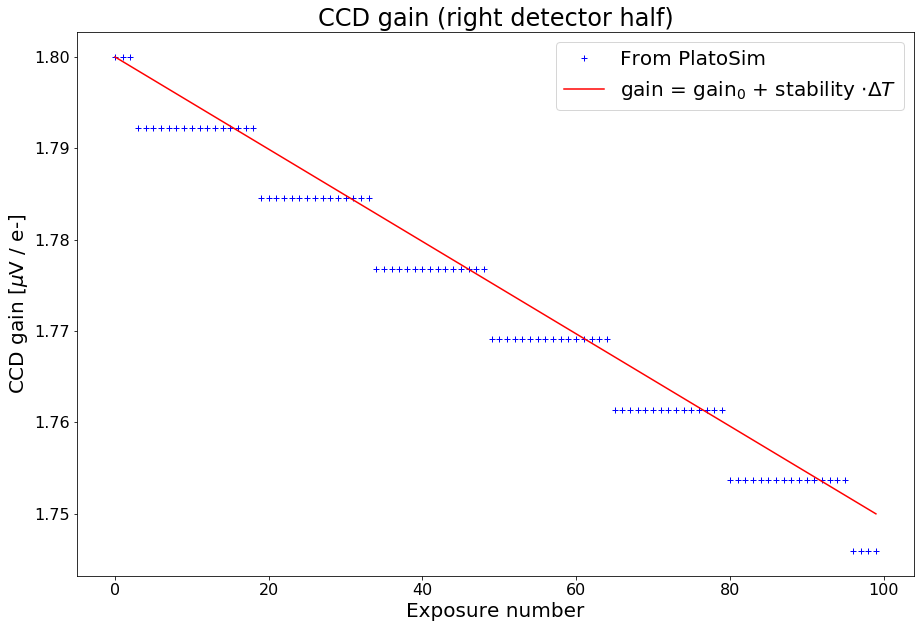

In [39]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############


ccdGain /= ccdGain[0]
ccdGain *= sim["CCD/Gain/RefValueRight"]
plt.plot(ccdGain, "b+", label="From PlatoSim")



##########################################################
# Linear decrease in FEE gain with increase in temperature
##########################################################

ccdSlope = (temperature[-1] - temperature[0]) / (numExposures - 1) * sim["CCD/Gain/Stability"]
exposures = np.arange(0, numExposures)
plt.plot(sim["CCD/Gain/RefValueRight"] + ccdSlope * exposures, "r", label = "gain = gain$_0$ + stability $\\cdot \\Delta T$")



########
# Layout
########

plt.title("CCD gain (right detector half)", fontsize = 24)
plt.xlabel("Exposure number", fontsize = 20)
plt.ylabel("CCD gain [$\mu$V / e-]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)